In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    df[col] = df[col].replace(0, df[col].median())

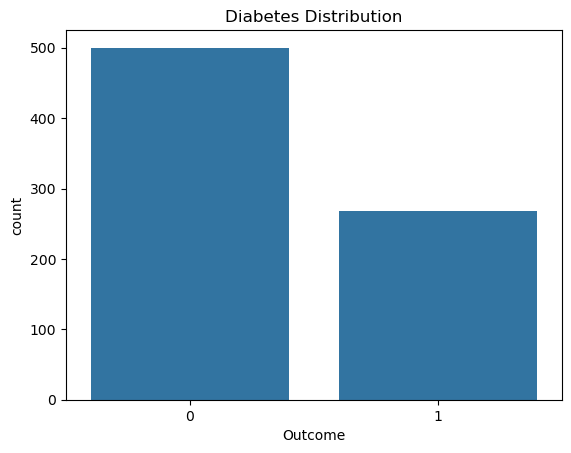

In [6]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Distribution")
plt.show()

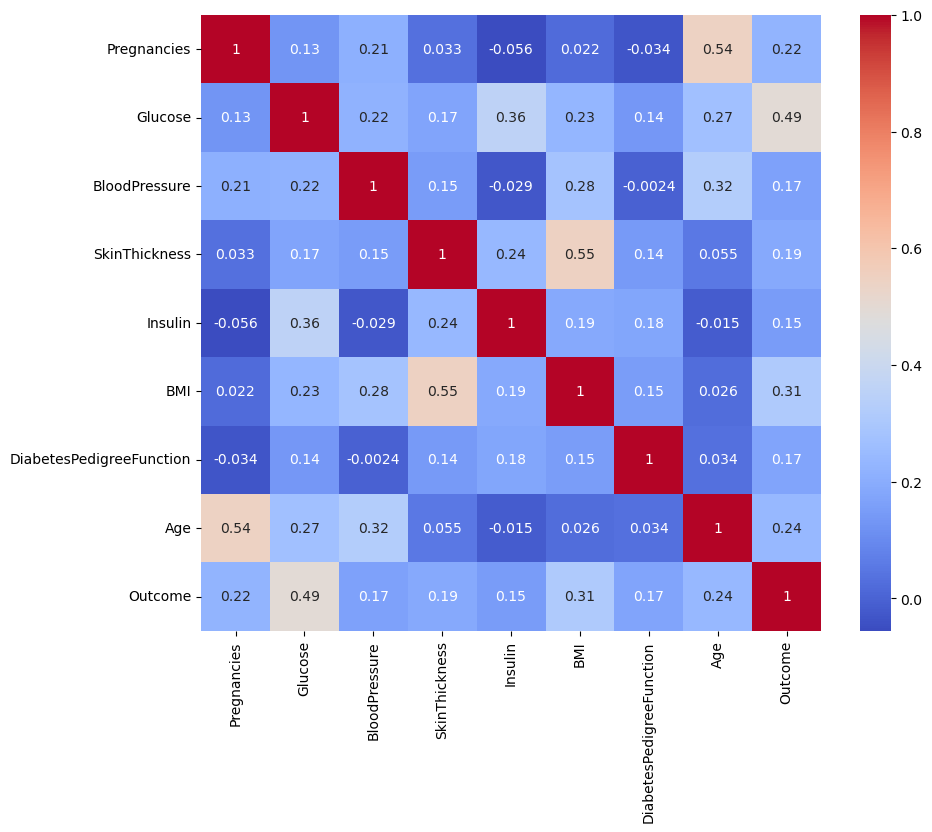

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [8]:
df['BMI_Age'] = df['BMI'] * df['Age']
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Age_Squared'] = df['Age']**2

In [9]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=300),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Bagging": BaggingClassifier(n_estimators=200),
    "AdaBoost": AdaBoostClassifier(n_estimators=200),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05)
}

In [13]:
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200)),
        ('xgb', XGBClassifier(n_estimators=200)),
        ('svm', SVC(probability=True))
    ],
    voting='soft'
)

models["Voting"] = voting

In [14]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5).mean()
    results.append([name, acc, cv])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

In [15]:
results_df = pd.DataFrame(results, columns=["Model", "Test Accuracy", "CV Accuracy"])
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print(results_df)

           Model  Test Accuracy  CV Accuracy
7        XGBoost       0.766234     0.743545
4        Bagging       0.753247     0.751388
2  Random Forest       0.746753     0.756600
6            SVM       0.746753     0.777379
8         Voting       0.740260     0.753968
5       AdaBoost       0.733766     0.754019
0       Logistic       0.714286     0.765674
3            KNN       0.707792     0.763093
1  Decision Tree       0.675325     0.730592


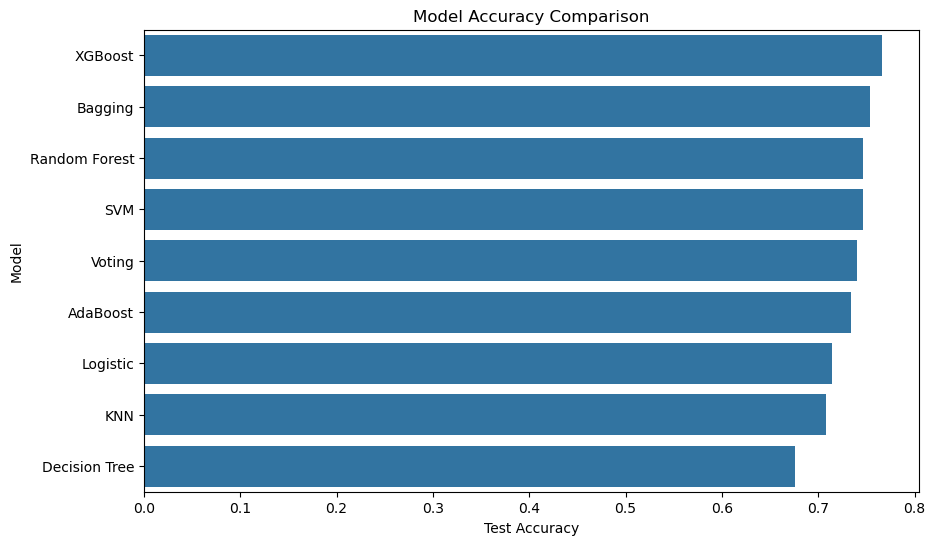

In [16]:
plt.figure(figsize=(10,6))
sns.barplot(x="Test Accuracy", y="Model", data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()

In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

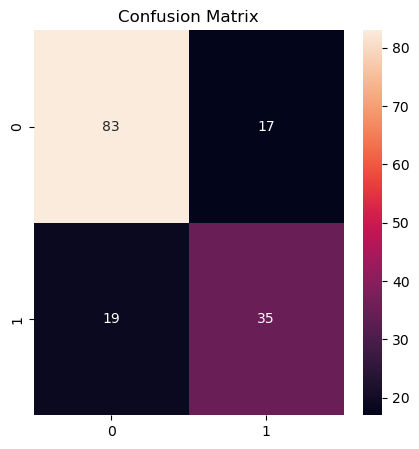

In [18]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



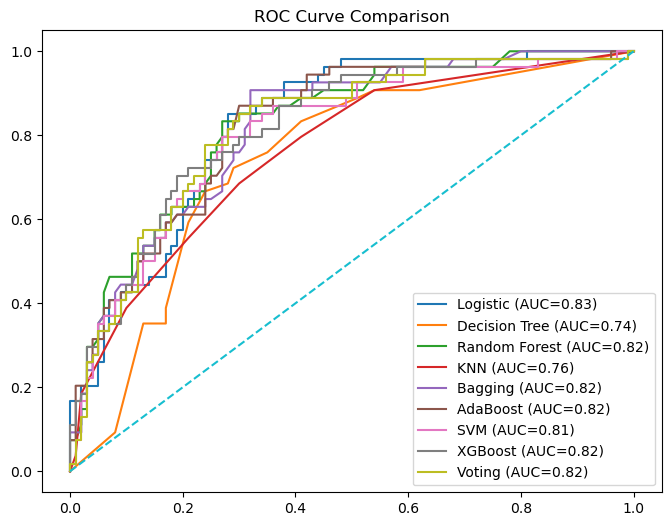

In [20]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

In [21]:
param_grid = {
    'n_estimators': [200,300],
    'max_depth': [None,5,10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 300}


In [22]:
best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = best_rf.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred))

Tuned Accuracy: 0.7142857142857143


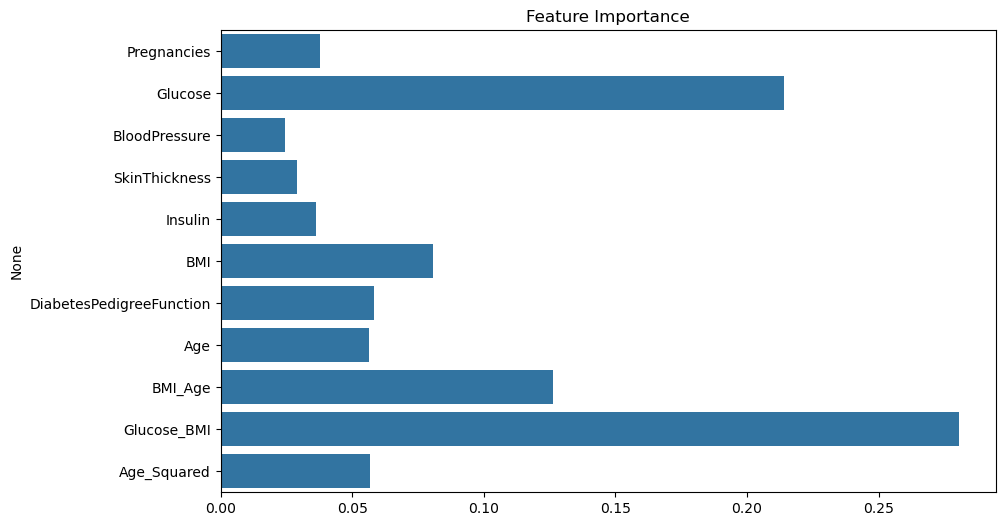

In [24]:
importances = best_rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()

In [25]:
final_cv = cross_val_score(best_rf, X, y, cv=5)
print("Final CV Accuracy:", final_cv.mean())

Final CV Accuracy: 0.7604617604617605


In [26]:
import pickle
pickle.dump(best_rf, open("diabetes_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))

In [27]:
model = pickle.load(open("diabetes_model.pkl","rb"))

In [28]:
sample = X_test[0].reshape(1,-1)
print("Prediction:", model.predict(sample))

Prediction: [1]


In [29]:
print("Final Model Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Final Model Accuracy: 0.7142857142857143
